### **Employee Analytics Workflow** -- **Parallel Workflow of LangGraph**

In [2]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = ChatGoogleGenerativeAI(
    model = "gemini-3.6-flash"
)


print(f"[INFO] Model : {model.model} Loaded Successfully!")

[INFO] Model : gemini-3.6-flash Loaded Successfully!


### **Creating the Employee State**

In [1]:
from typing import TypedDict

class EmployeeState(TypedDict):
    emp_name : str
    mon_salary : int
    working_days: int
    completed_projects : int

    yearly_salary : int
    bonus_amount : int
    project_status : str
    summary : str
    

### **Node-1 : Calculate yearly salary**

In [11]:
def cal_yearly_salary(state: EmployeeState):
    yearly_salary = state['mon_salary'] * 12
    return {
        'yearly_salary' : yearly_salary
    }

### **Node-2 : Calculate Bonus**

In [12]:
def cal_bonus(state: EmployeeState) -> EmployeeState:
    bonus_amount = state['mon_salary'] * 2
    return {
        'bonus_amount': bonus_amount
    }

### **Node-3: Project Evaluation**

In [13]:
def project_eval(state: EmployeeState):
    if state['completed_projects'] >= 5:
        status = 'Excellent'
    else:
        status = 'Average'
    return {
        'project_status' : status
    }

### **Node-4: Summary Node**

In [14]:
def summary(state: EmployeeState)->EmployeeState:
    summary_text = f"""
    Employee {state['emp_name']} has a yearly salary of INR {state['yearly_salary']} and a bonus amount of {state['bonus_amount']}.
    Project status of the Employee {state['project_status']}.
    """
    return {
        "summary" : summary_text
    }

### **Creating the State Graph**

In [15]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(EmployeeState)

graph.add_node("cal_yearly_salary", cal_yearly_salary)
graph.add_node("cal_bonus", cal_bonus)
graph.add_node("project_eval", project_eval)
graph.add_node("summary", summary)

graph.add_edge(START, "cal_yearly_salary")
graph.add_edge(START, "cal_bonus")
graph.add_edge(START, "project_eval")
graph.add_edge("cal_yearly_salary","summary")
graph.add_edge("cal_bonus","summary")
graph.add_edge("project_eval","summary")
graph.add_edge("summary", END)

### **Compiling the Workflow**

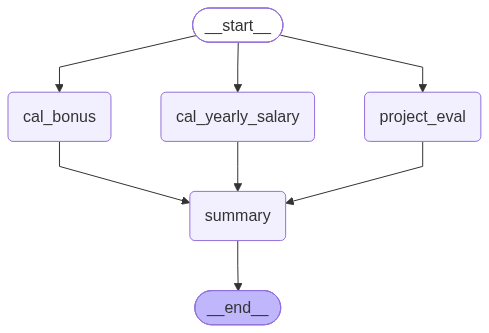

In [16]:
workflow = graph.compile()
workflow

In [17]:
initial_state = {
    "emp_name" : "manabendu karfa",
    "mon_salary" : 125000,
    "working days" : 22,
    "completed_projects" : 7
}

In [ ]:
result = workflow.invoke(
    
)